# Bonus

## Another diffusion model that improves upon DiffusionUNet

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
train_root = "data/afhq_64/train"
test_root = "data/afhq_64/test"

In [3]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])

train_dataset = datasets.ImageFolder(
    root=train_root,
    transform=transform,
)

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2 if os.name != "nt" else 0,
    pin_memory=True,
    drop_last=True,
)

images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Classes:", train_dataset.classes)

Images: torch.Size([32, 3, 64, 64])
Labels: torch.Size([32])
Classes: ['cat', 'dog', 'wild']


In [4]:
def make_group_norm(channels: int, max_groups: int = 32) -> nn.GroupNorm:
    """
    Creates GroupNorm with a valid number of groups.
    """
    groups = min(max_groups, channels)
    while channels % groups != 0:
        groups -= 1
    return nn.GroupNorm(groups, channels)

In [5]:
class SinusoidalTimeEmbedding(nn.Module):
    """
    Converts scalar diffusion timestep t into a sinusoidal embedding.
    """

    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """
        t: [B]
        returns: [B, dim]
        """
        half_dim = self.dim // 2
        device = t.device

        exponent = -math.log(10000) * torch.arange(
            half_dim, device=device, dtype=torch.float32
        ) / max(half_dim - 1, 1)

        freqs = torch.exp(exponent)
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)

        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)

        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))

        return emb


In [6]:
class TimeMLP(nn.Module):
    """
    Projects sinusoidal timestep embedding into a learned time embedding.
    """

    def __init__(self, emb_dim: int, hidden_dim: int):
        super().__init__()

        self.net = nn.Sequential(
            SinusoidalTimeEmbedding(emb_dim),
            nn.Linear(emb_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        return self.net(t)


In [7]:
class ResBlock(nn.Module):
    """
    Residual block with timestep conditioning.
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        time_dim: int,
        dropout: float = 0.0,
    ):
        super().__init__()

        self.norm1 = make_group_norm(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        self.time_proj = nn.Linear(time_dim, out_channels)

        self.norm2 = make_group_norm(out_channels)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x: torch.Tensor, time_emb: torch.Tensor) -> torch.Tensor:
        """
        x: [B, C, H, W]
        time_emb: [B, time_dim]
        """
        h = self.conv1(F.silu(self.norm1(x)))

        time_out = self.time_proj(F.silu(time_emb))
        h = h + time_out[:, :, None, None]

        h = self.conv2(self.dropout(F.silu(self.norm2(h))))

        return h + self.shortcut(x)


In [8]:

class AttentionBlock(nn.Module):
    """
    Spatial self-attention block.
    Useful at lower resolutions where H*W is not too large.
    """

    def __init__(self, channels: int, num_heads: int = 4):
        super().__init__()

        if channels % num_heads != 0:
            raise ValueError(
                f"channels={channels} must be divisible by num_heads={num_heads}"
            )

        self.channels = channels
        self.num_heads = num_heads
        self.head_dim = channels // num_heads

        self.norm = make_group_norm(channels)
        self.qkv = nn.Conv2d(channels, channels * 3, kernel_size=1)
        self.proj = nn.Conv2d(channels, channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, C, H, W]
        """
        b, c, h, w = x.shape

        h_norm = self.norm(x)
        qkv = self.qkv(h_norm)

        qkv = qkv.reshape(
            b,
            3,
            self.num_heads,
            self.head_dim,
            h * w,
        )

        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]

        scale = self.head_dim ** -0.5
        attn = torch.einsum("bhdn,bhdm->bhnm", q * scale, k)
        attn = attn.softmax(dim=-1)

        out = torch.einsum("bhnm,bhdm->bhdn", attn, v)
        out = out.reshape(b, c, h, w)

        return x + self.proj(out)

In [9]:
class Downsample(nn.Module):
    """
    Reduces spatial resolution by 2.
    """

    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            stride=2,
            padding=1,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class Upsample(nn.Module):
    """
    Increases spatial resolution by 2.
    """

    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        return self.conv(x)


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ClassConditionedDiffusionUNet(nn.Module):
    """
    Class-conditional DDPM U-Net with classifier-free guidance support.

    y:
        class labels: 0=cat, 1=dog, 2=wild
        None means unconditional prediction.
    """

    def __init__(
        self,
        in_channels=3,
        out_channels=3,
        num_classes=3,
        base_channels=64,
        channel_mults=(1, 2, 4),
        num_res_blocks=2,
        time_emb_dim=256,
        attention_levels=(2,),
        num_heads=4,
        dropout=0.1,
        cond_drop_prob=0.1,
    ):
        super().__init__()

        self.num_classes = num_classes
        self.null_class_id = num_classes
        self.cond_drop_prob = cond_drop_prob

        self.time_mlp = TimeMLP(
            emb_dim=base_channels,
            hidden_dim=time_emb_dim,
        )

        # +1 for unconditional/null label
        self.class_emb = nn.Embedding(num_classes + 1, time_emb_dim)

        self.init_conv = nn.Conv2d(
            in_channels,
            base_channels,
            kernel_size=3,
            padding=1,
        )

        self.downs = nn.ModuleList()
        skip_channels = []

        current_channels = base_channels

        for level, mult in enumerate(channel_mults):
            out_channels_level = base_channels * mult

            for _ in range(num_res_blocks):
                self.downs.append(
                    nn.ModuleList([
                        ResBlock(
                            current_channels,
                            out_channels_level,
                            time_dim=time_emb_dim,
                            dropout=dropout,
                        ),
                        AttentionBlock(out_channels_level, num_heads)
                        if level in attention_levels
                        else nn.Identity(),
                    ])
                )

                current_channels = out_channels_level
                skip_channels.append(current_channels)

            if level != len(channel_mults) - 1:
                self.downs.append(Downsample(current_channels))

        self.mid_block1 = ResBlock(
            current_channels,
            current_channels,
            time_dim=time_emb_dim,
            dropout=dropout,
        )

        self.mid_attn = AttentionBlock(current_channels, num_heads)

        self.mid_block2 = ResBlock(
            current_channels,
            current_channels,
            time_dim=time_emb_dim,
            dropout=dropout,
        )

        self.ups = nn.ModuleList()

        for level, mult in reversed(list(enumerate(channel_mults))):
            out_channels_level = base_channels * mult

            for _ in range(num_res_blocks):
                skip_ch = skip_channels.pop()

                self.ups.append(
                    nn.ModuleList([
                        ResBlock(
                            current_channels + skip_ch,
                            out_channels_level,
                            time_dim=time_emb_dim,
                            dropout=dropout,
                        ),
                        AttentionBlock(out_channels_level, num_heads)
                        if level in attention_levels
                        else nn.Identity(),
                    ])
                )

                current_channels = out_channels_level

            if level != 0:
                self.ups.append(Upsample(current_channels))

        self.final_norm = make_group_norm(current_channels)

        self.final_conv = nn.Conv2d(
            current_channels,
            out_channels,
            kernel_size=3,
            padding=1,
        )

    def make_condition_embedding(self, t, y=None):
        time_emb = self.time_mlp(t)

        batch_size = t.shape[0]

        if y is None:
            y = torch.full(
                (batch_size,),
                self.null_class_id,
                device=t.device,
                dtype=torch.long,
            )
        else:
            y = y.to(t.device)

            if self.training and self.cond_drop_prob > 0:
                drop_mask = torch.rand(batch_size, device=t.device) < self.cond_drop_prob
                y = y.clone()
                y[drop_mask] = self.null_class_id

        class_emb = self.class_emb(y)

        return time_emb + class_emb

    def forward(self, x, t, y=None):
        time_emb = self.make_condition_embedding(t, y)

        x = self.init_conv(x)

        skips = []

        for layer in self.downs:
            if isinstance(layer, nn.ModuleList):
                res_block, attn = layer
                x = res_block(x, time_emb)
                x = attn(x)
                skips.append(x)
            else:
                x = layer(x)

        x = self.mid_block1(x, time_emb)
        x = self.mid_attn(x)
        x = self.mid_block2(x, time_emb)

        for layer in self.ups:
            if isinstance(layer, nn.ModuleList):
                skip = skips.pop()

                if x.shape[-2:] != skip.shape[-2:]:
                    x = F.interpolate(
                        x,
                        size=skip.shape[-2:],
                        mode="nearest",
                    )

                x = torch.cat([x, skip], dim=1)

                res_block, attn = layer
                x = res_block(x, time_emb)
                x = attn(x)
            else:
                x = layer(x)

        x = self.final_conv(F.silu(self.final_norm(x)))

        return x

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [15]:
num_classes = len(train_dataset.classes)

cfg_model = ClassConditionedDiffusionUNet(
    in_channels=3,
    out_channels=3,
    num_classes=num_classes,
    base_channels=64,
    channel_mults=(1, 2, 4),
    num_res_blocks=2,
    time_emb_dim=256,
    attention_levels=(2,),
    num_heads=4,
    dropout=0.1,
    cond_drop_prob=0.1,
).to(device)

optimizer = torch.optim.AdamW(
    cfg_model.parameters(),
    lr=2e-4,
    weight_decay=1e-4,
)

print("Classes:", train_dataset.classes)

Classes: ['cat', 'dog', 'wild']


In [17]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

T = 1000

def linear_beta_schedule(timesteps):
    beta_start = 1e-4
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

betas = linear_beta_schedule(T).to(device)

alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

alphas_cumprod_prev = torch.cat([
    torch.tensor([1.0], device=device),
    alphas_cumprod[:-1],
])

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

posterior_variance = betas * (
    1.0 - alphas_cumprod_prev
) / (
    1.0 - alphas_cumprod
)


def extract(values, t, x_shape):
    batch_size = t.shape[0]
    out = values.gather(0, t)
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))


def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)

    sqrt_alpha_bar_t = extract(sqrt_alphas_cumprod, t, x_start.shape)
    sqrt_one_minus_alpha_bar_t = extract(
        sqrt_one_minus_alphas_cumprod,
        t,
        x_start.shape,
    )

    return sqrt_alpha_bar_t * x_start + sqrt_one_minus_alpha_bar_t * noise

In [18]:
from pathlib import Path
from tqdm.auto import tqdm
import torch.nn.functional as F

checkpoint_dir = Path("checkpoints_cfg")
checkpoint_dir.mkdir(exist_ok=True)

epochs = 100
log_every = 50
global_step = 0

for epoch in range(1, epochs + 1):
    cfg_model.train()
    running_loss = 0.0

    progress = tqdm(train_loader, desc=f"CFG Epoch {epoch}/{epochs}")

    for step, (x_start, labels) in enumerate(progress):
        x_start = x_start.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        batch_size = x_start.shape[0]

        t = torch.randint(
            low=0,
            high=T,
            size=(batch_size,),
            device=device,
            dtype=torch.long,
        )

        noise = torch.randn_like(x_start)
        x_noisy = q_sample(x_start=x_start, t=t, noise=noise)

        optimizer.zero_grad(set_to_none=True)

        predicted_noise = cfg_model(x_noisy, t, labels)
        loss = F.mse_loss(predicted_noise, noise)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(cfg_model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        global_step += 1

        if step % log_every == 0:
            progress.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = running_loss / len(train_loader)

    print(f"CFG Epoch {epoch} | Average loss: {avg_loss:.6f}")

    checkpoint_path = checkpoint_dir / f"afhq_cfg_ddpm_epoch_{epoch:03d}.pt"

    torch.save(
        {
            "epoch": epoch,
            "global_step": global_step,
            "model_state_dict": cfg_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss": avg_loss,
            "T": T,
            "classes": train_dataset.classes,
        },
        checkpoint_path,
    )

    print("Saved:", checkpoint_path)

CFG Epoch 1/100:   0%|          | 0/448 [00:00<?, ?it/s]

CFG Epoch 1 | Average loss: 0.082632
Saved: checkpoints_cfg/afhq_cfg_ddpm_epoch_001.pt


CFG Epoch 2/100:   0%|          | 0/448 [00:00<?, ?it/s]

CFG Epoch 2 | Average loss: 0.045325
Saved: checkpoints_cfg/afhq_cfg_ddpm_epoch_002.pt


CFG Epoch 3/100:   0%|          | 0/448 [00:00<?, ?it/s]

...

CFG Epoch 99/100:   0%|          | 0/448 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a90cdf509a0>
Exception ignored in: Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x7a90cdf509a0>  File "/home/user/elkhayata1/myenv22/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1663, in __del__

Exception ignored in: Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x7a90cdf509a0>      File "/home/user/elkhayata1/myenv22/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1663, in __del__
self._shutdown_workers()
    
self._shutdown_workers()Traceback (most recent call last):
  File "/home/user/elkhayata1/myenv22/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1663, in __del__
  File "/home/user/elkhayata1/myenv22/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1646, in _shutdown_workers
    
      File "/home/user/elkhayata1/myenv22/lib/python3.12/site-pac

CFG Epoch 99 | Average loss: 0.028928
Saved: checkpoints_cfg/afhq_cfg_ddpm_epoch_099.pt


CFG Epoch 100/100:   0%|          | 0/448 [00:00<?, ?it/s]

CFG Epoch 100 | Average loss: 0.029510
Saved: checkpoints_cfg/afhq_cfg_ddpm_epoch_100.pt


In [30]:
@torch.no_grad()
def p_sample_cfg(model, x, t, t_index, labels, guidance_scale=2.0):
    """
    One reverse diffusion step for class-conditioned diffusion
    using classifier-free guidance.
    """
    betas_t = extract(betas, t, x.shape)

    sqrt_one_minus_alphas_cumprod_t = extract(
        sqrt_one_minus_alphas_cumprod,
        t,
        x.shape,
    )

    sqrt_recip_alphas_t = extract(
        sqrt_recip_alphas,
        t,
        x.shape,
    )

    # Conditional prediction
    eps_cond = model(x, t, labels)

    # Unconditional prediction
    eps_uncond = model(x, t, None)

    # Classifier-free guidance
    predicted_noise = eps_uncond + guidance_scale * (eps_cond - eps_uncond)

    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * predicted_noise / sqrt_one_minus_alphas_cumprod_t
    )

    if t_index == 0:
        return model_mean

    posterior_variance_t = extract(posterior_variance, t, x.shape)
    noise = torch.randn_like(x)

    return model_mean + torch.sqrt(posterior_variance_t) * noise

In [31]:
@torch.no_grad()
def generate_class_samples(
    model,
    class_id,
    batch_size=16,
    image_size=64,
    guidance_scale=2.0,
):
    model.eval()

    x = torch.randn(
        batch_size,
        3,
        image_size,
        image_size,
        device=device,
    )

    labels = torch.full(
        (batch_size,),
        class_id,
        device=device,
        dtype=torch.long,
    )

    for t_index in tqdm(reversed(range(T)), total=T, desc=f"Generating class {class_id}"):
        t = torch.full(
            (batch_size,),
            t_index,
            device=device,
            dtype=torch.long,
        )

        x = p_sample_cfg(
            model=model,
            x=x,
            t=t,
            t_index=t_index,
            labels=labels,
            guidance_scale=guidance_scale,
        )

    x = x.clamp(-1, 1)
    return x

Generating class 0:   0%|          | 0/1000 [00:00<?, ?it/s]

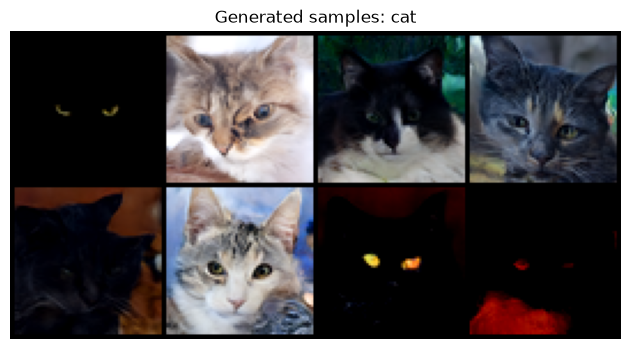

Generating class 1:   0%|          | 0/1000 [00:00<?, ?it/s]

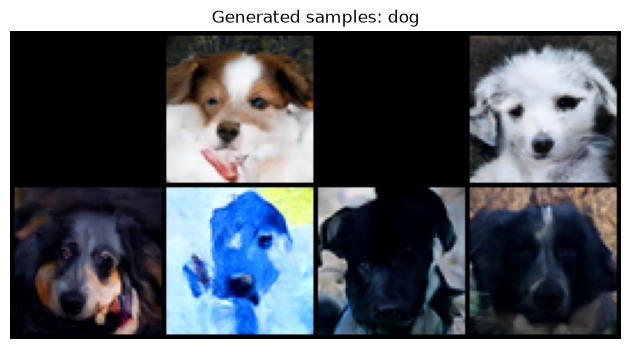

Generating class 2:   0%|          | 0/1000 [00:00<?, ?it/s]

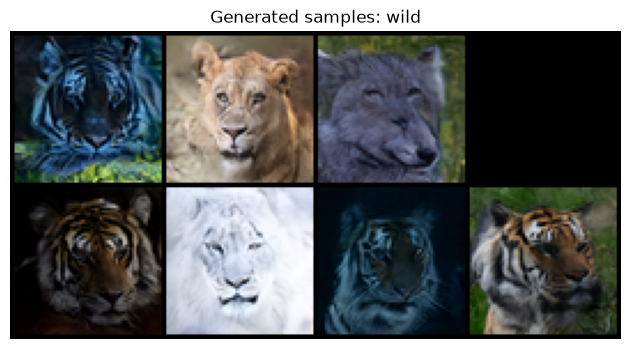

In [33]:
for class_id, class_name in enumerate(train_dataset.classes):
    samples = generate_class_samples(
        model=cfg_model,
        class_id=class_id,
        batch_size=8,
        image_size=64,
        guidance_scale=2.0,
    )

    samples_display = ((samples + 1) / 2).clamp(0, 1)

    grid = make_grid(samples_display, nrow=4)

    plt.figure(figsize=(8, 4))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis("off")
    plt.title(f"Generated samples: {class_name}")
    plt.show()

    save_image(samples_display, f"cfg_generated_{class_name}.png", nrow=4)

## Class-Conditioned Diffusion Generation Results

The class-conditioned diffusion model was trained to generate AFHQ animal faces using both random Gaussian noise and a class label. The AFHQ classes used in this experiment are `cat`, `dog`, and `wild`.

The generation process can be written as:

```text
x_T, y_class -> x_0
```

where:

```text
x_T      = initial Gaussian noise
y_class  = class label: cat, dog, or wild
x_0      = final generated image
```

The normal diffusion model generates images from noise only:

```text
x_T -> x_0
```

Because the normal diffusion model has no class label, the output class is uncontrolled. It may generate a cat, dog, wild animal, or an ambiguous animal face. In contrast, the class-conditioned diffusion model uses the class label to guide the denoising process toward a selected class:

```text
x_T, y_class -> x_0
```

The generated cat samples show that the model learned cat-specific features such as pointed ears, cat-like eyes, fur texture, and frontal face structure. Most cat samples are recognizable, although some outputs are very dark or nearly black, showing that the model is not fully stable.

The generated dog samples show different dog-like faces with longer snouts, floppy ears, varied fur colors, and breed-like variation. The dog class is mostly successful, but there are still unstable samples, including very dark images and one highly saturated sample.

The generated wild samples are strong compared with the other classes. Several samples resemble wild animals such as tigers, lions, wolves, or wild cats. This suggests that the model learned the visual structure of the wild class relatively well.

| Criterion | Normal Diffusion | Class-Conditioned Diffusion |
|---|---|---|
| Generation input | Random noise only | Random noise + class label |
| Class control | No control | Direct control |
| Output class | Random or mixed | Selected by the class label |
| Consistency | Less consistent | More class-consistent |
| Interpretability | Lower | Higher |
| Failure cases | Blank, noisy, or ambiguous images | Still possible, but class direction is clearer |

Compared with the autoencoder, the class-conditioned diffusion model produces sharper and more realistic images when it succeeds. However, the autoencoder is more stable, faster, and easier to analyze through its latent space.

The autoencoder generation process is:

```text
z -> decoded image
```

where `z` is a sampled latent vector. The class-conditioned diffusion process is:

```text
x_T, y_class -> x_0
```

| Criterion | Autoencoder | Class-Conditioned Diffusion |
|---|---|---|
| Generation input | Latent vector `z` | Noise `x_T` + class label `y_class` |
| Image sharpness | More blurry | Sharper when successful |
| Stability | More stable | Less stable |
| Class control | Indirect | Direct |
| Sampling speed | Fast | Slow |
| Interpolation | Smooth latent-space interpolation | Less stable noise-space interpolation |
| Main strength | Latent-space analysis | Controlled image generation |

Overall, the class-conditioned diffusion model improves upon the normal diffusion model because it can control the generated animal type. The generated cat, dog, and wild samples mostly match their target labels, which shows that the conditioning mechanism is working.

However, the model still has some failure cases. Some generated images are too dark, overexposed, or distorted. This suggests that the model would benefit from longer training, improved sampling, or more stable guidance settings.

In conclusion, the normal diffusion model is useful for general animal-face generation, the class-conditioned diffusion model is better for controlled class-specific generation, and the autoencoder is better for smooth interpolation and latent-space analysis. The conditioned diffusion model gives the best class control and strongest visual quality when it succeeds.

# Visualize Denoising Trajectory

In [25]:
@torch.no_grad()
def denoising_trajectory_cfg(
    model,
    class_id,
    image_size=64,
    guidance_scale=2.0,
    save_steps=(999, 750, 500, 250, 100, 50, 0),
):
    model.eval()

    x = torch.randn(1, 3, image_size, image_size, device=device)

    labels = torch.tensor([class_id], device=device, dtype=torch.long)

    saved_images = []
    saved_step_labels = []

    for t_index in tqdm(reversed(range(T)), total=T, desc=f"Denoising trajectory class {class_id}"):
        t = torch.full(
            (1,),
            t_index,
            device=device,
            dtype=torch.long,
        )

        x = p_sample_cfg(
            model=model,
            x=x,
            t=t,
            t_index=t_index,
            labels=labels,
            guidance_scale=guidance_scale,
        )

        if t_index in save_steps:
            img = x.clamp(-1, 1)
            img = ((img + 1) / 2).clamp(0, 1)
            saved_images.append(img.squeeze(0).cpu())
            saved_step_labels.append(f"t={t_index}")

    return saved_images, saved_step_labels

Denoising trajectory class 0:   0%|          | 0/1000 [00:00<?, ?it/s]

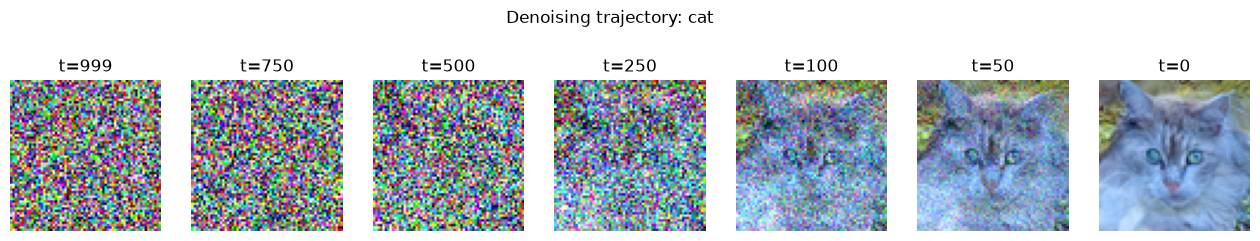

In [26]:
class_id = 0  # 0=cat, 1=dog, 2=wild
class_name = train_dataset.classes[class_id]

trajectory_images, trajectory_labels = denoising_trajectory_cfg(
    model=cfg_model,
    class_id=class_id,
    image_size=64,
    guidance_scale=2.0,
    save_steps=(999, 750, 500, 250, 100, 50, 0),
)

plt.figure(figsize=(16, 3))
for i, (img, label) in enumerate(zip(trajectory_images, trajectory_labels), 1):
    plt.subplot(1, len(trajectory_images), i)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(label)
    plt.axis("off")

plt.suptitle(f"Denoising trajectory: {class_name}")
plt.show()

## Normal Diffusion vs Class-Conditioned Diffusion

### Normal Diffusion Model

The normal diffusion model is unconditional. It learns the full AFHQ distribution without knowing whether the target image is a cat, dog, or wild animal.


In the normal diffusion trajectory, the model gradually removes noise and forms an animal-like image. However, because the model is not given a class label, it has to model all animal categories at once. This can make the generated result less controlled and less consistent. Some outputs may look like cats, dogs, or wild animals, while others may fail or become overexposed, dark, or noisy.

### Class-Conditioned Diffusion Model

The class-conditioned diffusion model receives the class label during generation. In this example, the class label is `cat`.

The denoising trajectory shows that the model starts from random noise at \(t=999\), then gradually forms cat-like structure. By \(t=100\) and \(t=50\), the face shape, ears, eyes, and fur texture become visible. At \(t=0\), the result is a clear cat face.

This shows that conditioning helps the model focus on a specific part of the AFHQ distribution instead of generating from all classes at once.

### Comparison Table

| Criterion | Normal Diffusion | Class-Conditioned Diffusion |
|---|---|---|
| Input during sampling | Random noise only | Random noise + class label |
| Control over output | No direct control | Can choose cat, dog, or wild |
| Learned distribution | Full AFHQ distribution | Class-specific AFHQ distribution |
| Denoising behavior | Forms a generic animal face | Forms a target class face |
| Output consistency | Less consistent | More class-consistent |
| Interpretability | Shows general denoising | Shows class-guided denoising |
| Failure mode | May produce mixed or ambiguous animals | May still fail, but class direction is clearer |
| Best use | Unconditional generation | Controlled class-specific generation |

### Main Observation

The class-conditioned diffusion model gives better control than the normal diffusion model. In the shown trajectory, the conditioned model clearly moves from noise toward a cat face. The class label helps the model decide what type of animal to generate.

The normal diffusion model can still generate recognizable animals, but the output class is random and less predictable. It may produce a cat, dog, or wild animal without control from the user.

### Conclusion

The class-conditioned diffusion model improves upon the normal diffusion model by adding controllability. Instead of sampling from the entire AFHQ distribution, it can sample from a selected class such as cat, dog, or wild. This makes the generated results easier to interpret and compare.

Overall, the normal diffusion model is useful for general animal-face generation, while the class-conditioned diffusion model is better for controlled generation because it guides the reverse denoising process toward a specific class.

# Interpolation

In [27]:
def slerp(alpha, x1, x2):
    """
    Spherical linear interpolation between two tensors.
    """
    x1_flat = x1.reshape(x1.shape[0], -1)
    x2_flat = x2.reshape(x2.shape[0], -1)

    x1_norm = F.normalize(x1_flat, dim=1)
    x2_norm = F.normalize(x2_flat, dim=1)

    dot = (x1_norm * x2_norm).sum(dim=1).clamp(-0.999, 0.999)
    theta = torch.acos(dot)
    sin_theta = torch.sin(theta)

    # Fallback to linear interpolation if sin(theta) is too small
    near_zero = sin_theta.abs() < 1e-6
    sin_theta = torch.where(near_zero, torch.ones_like(sin_theta), sin_theta)

    a = torch.sin((1 - alpha) * theta) / sin_theta
    b = torch.sin(alpha * theta) / sin_theta

    out = a[:, None] * x1_flat + b[:, None] * x2_flat
    return out.reshape_as(x1)

In [28]:
@torch.no_grad()
def conditional_diffusion_interpolation(
    model,
    class_id,
    steps=8,
    image_size=64,
    guidance_scale=2.0,
):
    model.eval()

    noise_a = torch.randn(1, 3, image_size, image_size, device=device)
    noise_b = torch.randn(1, 3, image_size, image_size, device=device)

    noises = []

    for alpha in torch.linspace(0, 1, steps, device=device):
        alpha = alpha.view(1)
        noise_interp = slerp(alpha, noise_a, noise_b)
        noises.append(noise_interp)

    x = torch.cat(noises, dim=0)

    labels = torch.full(
        (steps,),
        class_id,
        device=device,
        dtype=torch.long,
    )

    for t_index in tqdm(reversed(range(T)), total=T, desc=f"Interpolation class {class_id}"):
        t = torch.full(
            (steps,),
            t_index,
            device=device,
            dtype=torch.long,
        )

        x = p_sample_cfg(
            model=model,
            x=x,
            t=t,
            t_index=t_index,
            labels=labels,
            guidance_scale=guidance_scale,
        )

    x = x.clamp(-1, 1)
    return x

Interpolation class 1:   0%|          | 0/1000 [00:00<?, ?it/s]

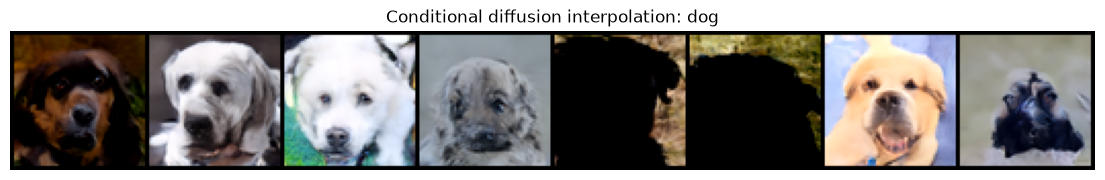

In [29]:
class_id = 1  # 0=cat, 1=dog, 2=wild
class_name = train_dataset.classes[class_id]

interp_samples = conditional_diffusion_interpolation(
    model=cfg_model,
    class_id=class_id,
    steps=8,
    image_size=64,
    guidance_scale=2.0,
)

interp_display = ((interp_samples + 1) / 2).clamp(0, 1)

grid = make_grid(interp_display, nrow=8)

plt.figure(figsize=(14, 3))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis("off")
plt.title(f"Conditional diffusion interpolation: {class_name}")
plt.show()

save_image(interp_display, f"cfg_interpolation_{class_name}.png", nrow=8)

## Conditional Diffusion Interpolation Comparison

### Conditional Diffusion Interpolation

The conditional diffusion interpolation result shows interpolation in noise space while keeping the class label fixed. In this example, the class is `dog`, so every interpolated sample is guided toward the dog category.



The main observation is that the generated images are mostly dog-like, which shows that conditioning improves semantic consistency. Even though the initial noise changes, the model still tries to generate dog faces. This is an improvement over normal diffusion interpolation, where the generated class may drift more freely.

However, the interpolation is still not perfectly smooth. Some frames are very dark, nearly black, or visually unstable. This suggests that although conditioning helps control the output class, interpolation in diffusion noise space remains less stable than interpolation in an autoencoder latent space.

### Comparison with Normal Diffusion Interpolation

In the normal diffusion interpolation, interpolation is performed between two noise vectors without any class condition. As a result, the generated images may vary more in animal type and structure, and the transition is less controlled.

With conditional diffusion interpolation:
- the output stays closer to the chosen class,
- the model produces more class-consistent results,
- but the interpolation can still contain unstable or failed samples.

### Comparison with Autoencoder Interpolation

The autoencoder still performs better for interpolation quality. Because it has an explicit latent space, interpolation is smoother and easier to interpret. In the autoencoder results, the transition between endpoints is gradual and visually continuous.

By contrast, conditional diffusion interpolation:
- gives better class control than unconditional diffusion,
- can produce sharper individual images,
- but is less smooth and less reliable than autoencoder interpolation.

### Comparison Table

| Criterion | Autoencoder Interpolation | Normal Diffusion Interpolation | Conditional Diffusion Interpolation |
|---|---|---|---|
| Interpolation space | Latent space | Noise space | Noise space + class label |
| Smoothness | Best | Weak | Better than normal diffusion, but still unstable |
| Class control | Indirect | None | Strong |
| Visual consistency | High | Low | Medium |
| Sharpness | Blurrier | Sometimes sharper | Sometimes sharper |
| Failure mode | Blurry transitions | Random/unstable samples | Black or unstable samples, but class is preserved better |
| Interpretability | High | Low | Medium |
| Sampling cost | Low | High | High |

### Main Conclusion

Conditional diffusion interpolation improves over normal diffusion interpolation because it keeps the generated samples closer to the chosen class. In this example, most samples remain dog-like, which shows that conditioning adds useful control.

However, the interpolation is still not as smooth as the autoencoder interpolation. The autoencoder remains the best model for latent-space interpolation and semantic continuity, while the conditional diffusion model is better when the goal is class-controlled generation.

Overall:
- **Autoencoder interpolation** is the smoothest and easiest to interpret.
- **Normal diffusion interpolation** is less controlled and more unstable.
- **Conditional diffusion interpolation** improves control and class consistency, but still has instability due to the stochastic reverse diffusion process.